In [1]:
### Basisc Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)
#### Paths
PROJECT_ROOT = Path("..")

DATA_DIR = PROJECT_ROOT / "Data" / "processed"
REPORT_DIR = PROJECT_ROOT / "Reports" / "project1"

TRAIN_PATH = DATA_DIR / "project1_train.csv"
VAL_PATH = DATA_DIR / "project1_validation.csv"
TEST_PATH = DATA_DIR / "project1_test.csv"

REPORT_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
### Load Datasets
train_df = pd.read_csv(TRAIN_PATH)
val_df = pd.read_csv(VAL_PATH)
test_df = pd.read_csv(TEST_PATH)

print("Train:", train_df.shape)
print("Validation:", val_df.shape)
print("Test:", test_df.shape)

Train: (58422, 18)
Validation: (11685, 18)
Test: (11685, 18)


In [3]:
### Final Frogen Configuration
TEXT_COL = "Consumer complaint narrative"
COMPANY_COL = "Company"
TARGET_COL = "Product"

WORD_NGRAM_RANGE = (1, 2)
CHAR_NGRAM_RANGE = (3, 5)

WORD_MAX_FEATURES = 10000
CHAR_MAX_FEATURES = 10000

LOGREG_C = 1.0
CLASS_WEIGHT = None

In [4]:
### Prepare Train + Validation
dev_df = pd.concat(
    [train_df, val_df],
    axis=0,
    ignore_index=True
)

X_dev_text = dev_df[TEXT_COL].fillna("")
X_dev_company = dev_df[[COMPANY_COL]].fillna("Missing")

y_dev = dev_df[TARGET_COL]

X_test_text = test_df[TEXT_COL].fillna("")
X_test_company = test_df[[COMPANY_COL]].fillna("Missing")

y_test = test_df[TARGET_COL]

print("Development rows:", len(dev_df))
print("Test rows:", len(test_df))
print("Development classes:", y_dev.nunique())
print("Test classes:", y_test.nunique())

Development rows: 70107
Test rows: 11685
Development classes: 11
Test classes: 11


In [5]:
## Fit Frozen Feature Representation
word_vectorizer = TfidfVectorizer(
    ngram_range=WORD_NGRAM_RANGE,
    max_features=WORD_MAX_FEATURES
)

char_vectorizer = TfidfVectorizer(
    analyzer="char",
    ngram_range=CHAR_NGRAM_RANGE,
    max_features=CHAR_MAX_FEATURES
)

company_encoder = OneHotEncoder(
    handle_unknown="ignore"
)

In [6]:
## Fit only on Develepment Data
X_word_dev = word_vectorizer.fit_transform(X_dev_text)
X_char_dev = char_vectorizer.fit_transform(X_dev_text)
X_company_dev = company_encoder.fit_transform(X_dev_company)

print("Word:", X_word_dev.shape)
print("Char:", X_char_dev.shape)
print("Company:", X_company_dev.shape)

Word: (70107, 10000)
Char: (70107, 10000)
Company: (70107, 1883)


In [7]:
## Transform Test
X_word_test = word_vectorizer.transform(X_test_text)
X_char_test = char_vectorizer.transform(X_test_text)
X_company_test = company_encoder.transform(X_test_company)

print("Word test:", X_word_test.shape)
print("Char test:", X_char_test.shape)
print("Company test:", X_company_test.shape)

Word test: (11685, 10000)
Char test: (11685, 10000)
Company test: (11685, 1883)


In [8]:
## Combine Frogen Features
from scipy.sparse import hstack

X_dev = hstack([
    X_word_dev,
    X_char_dev,
    X_company_dev
]).tocsr()

X_test = hstack([
    X_word_test,
    X_char_test,
    X_company_test
]).tocsr()

print("Development matrix:", X_dev.shape)
print("Test matrix:", X_test.shape)

Development matrix: (70107, 21883)
Test matrix: (11685, 21883)


In [9]:
### Train Final Frogen Models
final_model = LogisticRegression(
    C=LOGREG_C,
    class_weight=CLASS_WEIGHT,
    max_iter=1000
)

final_model.fit(X_dev, y_dev)

print("Final frozen model trained.")

Final frozen model trained.


### Final Test Predictions

In [10]:
y_test_pred = final_model.predict(X_test)
y_test_prob = final_model.predict_proba(X_test)

test_confidence = y_test_prob.max(axis=1)

print("Test predictions generated.")

Test predictions generated.


In [11]:
### Final Metrics
test_accuracy = accuracy_score(y_test, y_test_pred)
test_macro_f1 = f1_score(
    y_test,
    y_test_pred,
    average="macro"
)

test_weighted_f1 = f1_score(
    y_test,
    y_test_pred,
    average="weighted"
)

print("=" * 70)
print("FINAL TEST PERFORMANCE")
print("=" * 70)

print(f"Accuracy    : {test_accuracy:.4f}")
print(f"Macro F1    : {test_macro_f1:.4f}")
print(f"Weighted F1 : {test_weighted_f1:.4f}")

FINAL TEST PERFORMANCE
Accuracy    : 0.8651
Macro F1    : 0.7930
Weighted F1 : 0.8632


### Validation Vs Test
- Using the actually/Already established Validation numbers

In [12]:
validation_accuracy = 0.8680359435
validation_macro_f1 = 0.8043225939
validation_weighted_f1 = 0.8660806060

comparison = pd.DataFrame({
    "Metric": [
        "Accuracy",
        "Macro F1",
        "Weighted F1"
    ],
    "Validation": [
        validation_accuracy,
        validation_macro_f1,
        validation_weighted_f1
    ],
    "Test": [
        test_accuracy,
        test_macro_f1,
        test_weighted_f1
    ]
})

comparison["Test_minus_Validation"] = (
    comparison["Test"] - comparison["Validation"]
)

comparison

,Metric,Validation,Test,Test_minus_Validation
0,Accuracy,0.868036,0.865126,-0.002910
1,Macro F1,0.804323,0.792991,-0.011331
2,Weighted F1,0.866081,0.863177,-0.002903


### Per-Class Test Performance

In [13]:
test_report = classification_report(
    y_test,
    y_test_pred,
    output_dict=True,
    zero_division=0
)

test_report_df = pd.DataFrame(test_report).T

test_report_df

,precision,recall,f1-score,support
Checking or savings account,0.792813,0.852576,0.821609,2096.000000
Credit card,0.849357,0.838153,0.843718,1971.000000
Credit reporting or other personal consumer reports,0.830769,0.907563,0.867470,476.000000
Debt collection,0.932164,0.939189,0.935663,3848.000000
Debt or credit management,0.891892,0.320388,0.471429,103.000000
"Money transfer, virtual currency, or money service",0.750554,0.724064,0.737071,935.000000
Mortgage,0.949535,0.938320,0.943894,762.000000
"Payday loan, title loan, personal loan, or advance loan",0.739583,0.689320,0.713568,412.000000
Prepaid card,0.716049,0.446154,0.549763,130.000000
Student loan,0.966581,0.979167,0.972833,384.000000


In [14]:
## Inspection
test_report_df.loc[
    test_report_df.index.intersection(final_model.classes_)
]

,precision,recall,f1-score,support
Checking or savings account,0.792813,0.852576,0.821609,2096.0
Credit card,0.849357,0.838153,0.843718,1971.0
Credit reporting or other personal consumer reports,0.830769,0.907563,0.867470,476.0
Debt collection,0.932164,0.939189,0.935663,3848.0
Debt or credit management,0.891892,0.320388,0.471429,103.0
"Money transfer, virtual currency, or money service",0.750554,0.724064,0.737071,935.0
Mortgage,0.949535,0.938320,0.943894,762.0
"Payday loan, title loan, personal loan, or advance loan",0.739583,0.689320,0.713568,412.0
Prepaid card,0.716049,0.446154,0.549763,130.0
Student loan,0.966581,0.979167,0.972833,384.0


### Confusion Matrix

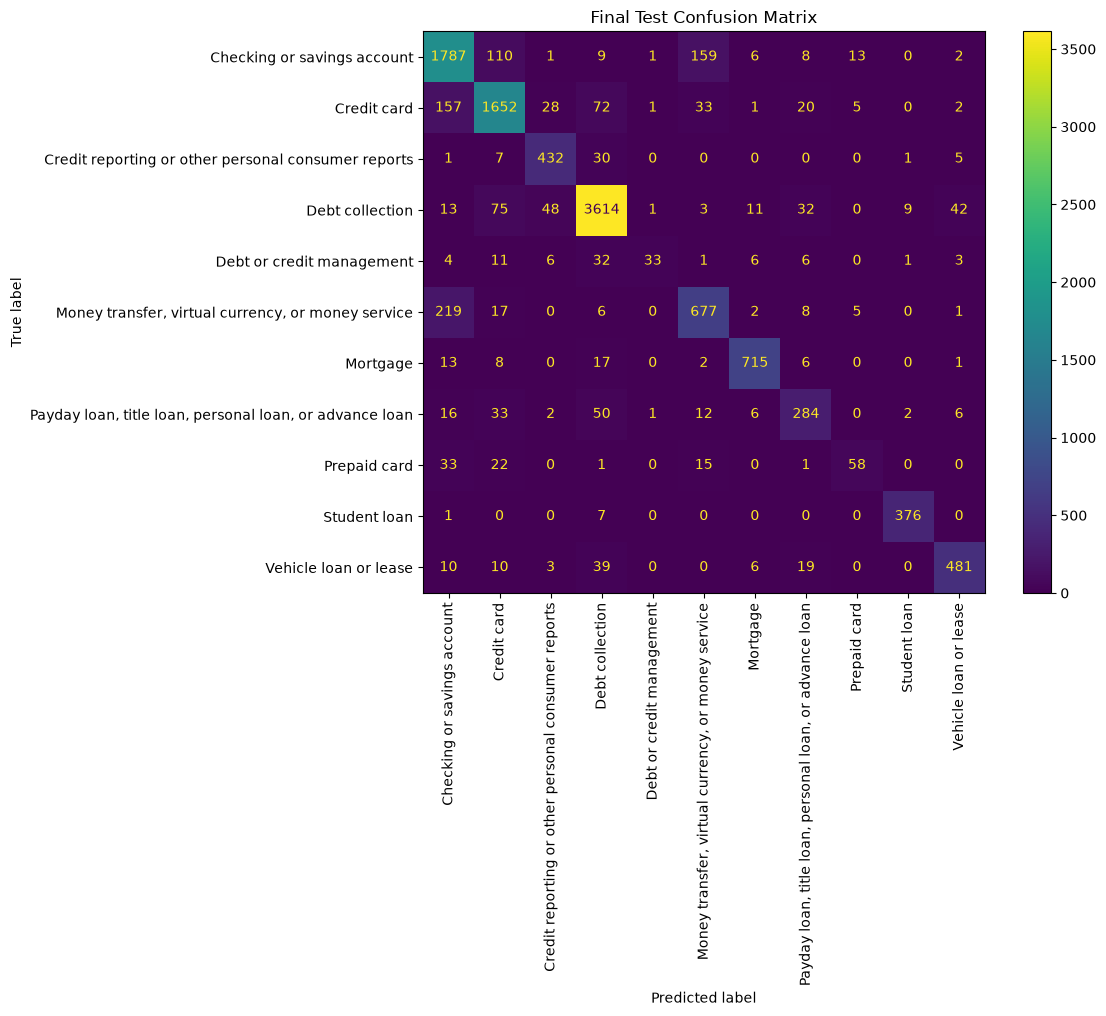

In [15]:
cm = confusion_matrix(
    y_test,
    y_test_pred,
    labels=final_model.classes_
)

fig, ax = plt.subplots(figsize=(12, 10))

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=final_model.classes_
)

disp.plot(
    ax=ax,
    xticks_rotation=90,
    values_format="d"
)

plt.title("Final Test Confusion Matrix")
plt.tight_layout()
plt.show()

In [16]:
### Ranked Confusion Pairs
confusion_pairs = []

classes = final_model.classes_

for i, actual in enumerate(classes):
    for j, predicted in enumerate(classes):
        if i != j and cm[i, j] > 0:
            confusion_pairs.append({
                "Actual_Product": actual,
                "Predicted_Product": predicted,
                "Errors": cm[i, j]
            })

confusion_pairs_df = (
    pd.DataFrame(confusion_pairs)
    .sort_values("Errors", ascending=False)
    .reset_index(drop=True)
)

confusion_pairs_df.head(15)

,Actual_Product,Predicted_Product,Errors
0,"Money transfer, virtual currency, or money ser...",Checking or savings account,219
1,Checking or savings account,"Money transfer, virtual currency, or money ser...",159
2,Credit card,Checking or savings account,157
3,Checking or savings account,Credit card,110
4,Debt collection,Credit card,75
5,Credit card,Debt collection,72
6,"Payday loan, title loan, personal loan, or adv...",Debt collection,50
7,Debt collection,Credit reporting or other personal consumer re...,48
8,Debt collection,Vehicle loan or lease,42
9,Vehicle loan or lease,Debt collection,39


In [17]:
## Then Inspecting Errors
total_test_errors = (y_test != y_test_pred).sum()

top10_errors = confusion_pairs_df.head(10)["Errors"].sum()

print("Total test errors:", total_test_errors)
print("Top 10 confusion errors:", top10_errors)
print(
    f"Share of all test errors: "
    f"{top10_errors / total_test_errors:.2%}"
)

Total test errors: 1576
Top 10 confusion errors: 971
Share of all test errors: 61.61%


In [18]:
### Confidence Analysis
test_analysis_df = test_df.copy()

test_analysis_df["Predicted_Product"] = y_test_pred
test_analysis_df["Correct"] = (
    test_analysis_df[TARGET_COL]
    == test_analysis_df["Predicted_Product"]
)

test_analysis_df["Prediction_Confidence"] = test_confidence

test_analysis_df[
    ["Correct", "Prediction_Confidence"]
].groupby("Correct")["Prediction_Confidence"].agg(
    ["count", "mean", "median", "min", "max"]
)

,count,mean,median,min,max
Correct,,,,,
False,1576,0.634426,0.625681,0.200866,0.998776
True,10109,0.880669,0.950073,0.194094,0.999966


In [19]:
### High-Confidence Test Errors
high_confidence_errors = (
    test_analysis_df[
        (test_analysis_df["Correct"] == False)
    ]
    .sort_values(
        "Prediction_Confidence",
        ascending=False
    )
)

high_confidence_errors[
    [
        TARGET_COL,
        "Predicted_Product",
        "Prediction_Confidence",
        COMPANY_COL,
        TEXT_COL
    ]
].head(20)

,Product,Predicted_Product,Prediction_Confidence,Company,Consumer complaint narrative
8845,Credit card,Debt collection,0.998776,"Portfolio Recovery Associates, LLC",I am submitting this complaint regarding a col...
7388,Debt collection,Mortgage,0.998389,"Rocket Mortgage, LLC",I am filing a complaint regarding improper han...
2869,Debt or credit management,Mortgage,0.998386,"United Shore Financial Services, LLC",Re : Complaint Against Mortgage Lender Uninhab...
626,"Money transfer, virtual currency, or money ser...",Mortgage,0.998101,"PLANET HOME LENDING, LLC",I am writing to file a formal complaint regard...
3409,Debt or credit management,Mortgage,0.998044,"PENNYMAC LOAN SERVICES, LLC.","We have a mortgage with the company, XXXX mon..."
6648,"Payday loan, title loan, personal loan, or adv...",Credit card,0.998000,"CITIBANK, N.A.",I am filing a complaint regarding duplicate ch...
3127,Debt or credit management,Debt collection,0.997661,CL Holdings LLC,I am filing a formal complaint regarding inacc...
7431,Debt or credit management,Debt collection,0.997545,"Firstsource Business Process Services, LLC",I am requesting validation of this debt. I hav...
3034,Credit card,Debt collection,0.996920,Resurgent Capital Services L.P.,This is the letter I sent to them. Now they ha...
9225,Credit card,Debt collection,0.996552,CL Holdings LLC,was never sent the debt validation from origin...


In [20]:
### Validation Vs Test Generalization Gap
print("=" * 70)
print("GENERALIZATION GAP")
print("=" * 70)

print(
    f"Accuracy gap    : "
    f"{test_accuracy - validation_accuracy:+.4f}"
)

print(
    f"Macro F1 gap    : "
    f"{test_macro_f1 - validation_macro_f1:+.4f}"
)

print(
    f"Weighted F1 gap : "
    f"{test_weighted_f1 - validation_weighted_f1:+.4f}"
)

GENERALIZATION GAP
Accuracy gap    : -0.0029
Macro F1 gap    : -0.0113
Weighted F1 gap : -0.0029


In [21]:
## Save the Final Results
comparison.to_csv(
    REPORT_DIR / "project1_validation_vs_test.csv",
    index=False
)

test_report_df.to_csv(
    REPORT_DIR / "project1_final_test_classification_report.csv"
)

confusion_pairs_df.to_csv(
    REPORT_DIR / "project1_final_test_confusion_pairs.csv",
    index=False
)

high_confidence_errors.to_csv(
    REPORT_DIR / "project1_final_test_high_confidence_errors.csv",
    index=False
)

test_analysis_df.to_csv(
    REPORT_DIR / "project1_final_test_predictions.csv",
    index=False
)

print("Final test reports saved.")

Final test reports saved.
